In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training data shape:", X_train.shape)
print("Training labels shape:", y_train.shape)
print("Testing data shape:", X_test.shape)
print("Testing labels shape:", y_test.shape)

Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Testing data shape: (10000, 28, 28)
Testing labels shape: (10000,)


In [2]:
unique_classes = np.unique(y_train)

print("Number of classes:", len(unique_classes))
print("Classes:", unique_classes)
print("Image size:", X_train.shape[1:])

Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]
Image size: (28, 28)


In [3]:
unique, counts = np.unique(y_train, return_counts=True)

print("Training samples per digit:")

for digit, count in zip(unique, counts):
    print(f"Digit {digit}: {count}")

Training samples per digit:
Digit 0: 5923
Digit 1: 6742
Digit 2: 5958
Digit 3: 6131
Digit 4: 5842
Digit 5: 5421
Digit 6: 5918
Digit 7: 6265
Digit 8: 5851
Digit 9: 5949


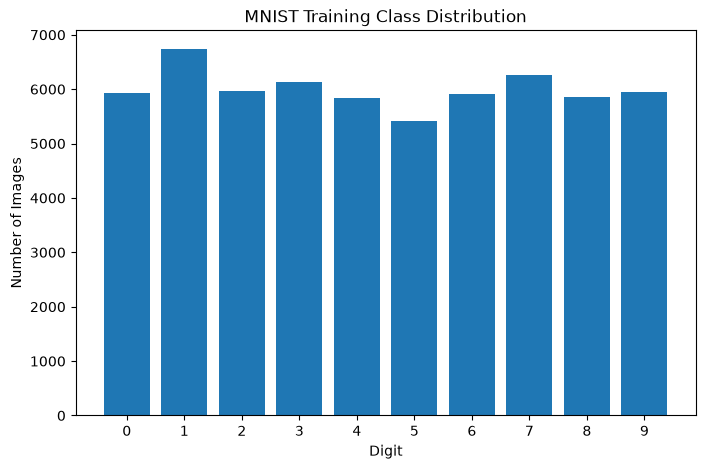

In [4]:
plt.figure(figsize=(8, 5))

plt.bar(unique, counts)

plt.title("MNIST Training Class Distribution")
plt.xlabel("Digit")
plt.ylabel("Number of Images")
plt.xticks(unique)

plt.show()

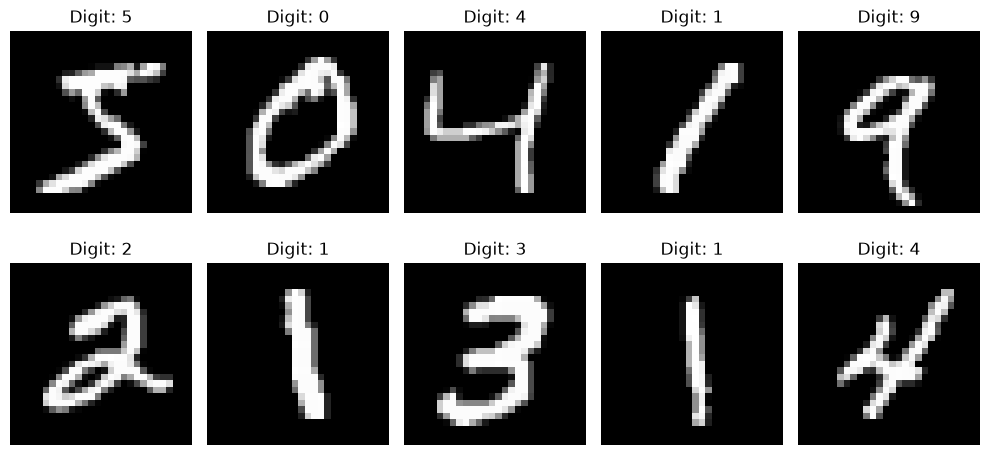

In [5]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Digit: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [6]:
print("Minimum pixel value:", X_train.min())
print("Maximum pixel value:", X_train.max())
print("Data type:", X_train.dtype)
print("Image shape:", X_train[0].shape)

Minimum pixel value: 0
Maximum pixel value: 255
Data type: uint8
Image shape: (28, 28)


In [7]:
# Normalize pixel values from 0-255 to 0-1
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)
print("Minimum pixel value after normalization:", X_train.min())
print("Maximum pixel value after normalization:", X_train.max())
print("Data type after normalization:", X_train.dtype)

Training data shape: (60000, 28, 28)
Testing data shape: (10000, 28, 28)
Minimum pixel value after normalization: 0.0
Maximum pixel value after normalization: 1.0
Data type after normalization: float32


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.1,
    random_state=42,
    stratify=y_train
)

print("Training set:", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)
print("Test set:", X_test.shape, y_test.shape)

Training set: (54000, 28, 28) (54000,)
Validation set: (6000, 28, 28) (6000,)
Test set: (10000, 28, 28) (10000,)


In [9]:
train_unique, train_counts = np.unique(y_train, return_counts=True)
val_unique, val_counts = np.unique(y_val, return_counts=True)

print("Training set class distribution:")
for digit, count in zip(train_unique, train_counts):
    print(f"Digit {digit}: {count}")

print("\nValidation set class distribution:")
for digit, count in zip(val_unique, val_counts):
    print(f"Digit {digit}: {count}")

Training set class distribution:
Digit 0: 5331
Digit 1: 6068
Digit 2: 5362
Digit 3: 5518
Digit 4: 5258
Digit 5: 4879
Digit 6: 5326
Digit 7: 5638
Digit 8: 5266
Digit 9: 5354

Validation set class distribution:
Digit 0: 592
Digit 1: 674
Digit 2: 596
Digit 3: 613
Digit 4: 584
Digit 5: 542
Digit 6: 592
Digit 7: 627
Digit 8: 585
Digit 9: 595


In [10]:
import tensorflow as tf

baseline_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
baseline_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Optimizer:", baseline_model.optimizer.name)
print("Loss function:", baseline_model.loss)
print("Metrics:", baseline_model.metrics_names)


Optimizer: adam
Loss function: sparse_categorical_crossentropy
Metrics: ['loss', 'compile_metrics']


In [12]:




EPOCHS = 10
BATCH_SIZE = 128

print("Epochs:", EPOCHS)
print("Batch size:", BATCH_SIZE)
print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))

Epochs: 10
Batch size: 128
Training samples: 54000
Validation samples: 6000


In [13]:
history = baseline_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8964 - loss: 0.3706 - val_accuracy: 0.9383 - val_loss: 0.2275
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9509 - loss: 0.1743 - val_accuracy: 0.9517 - val_loss: 0.1690
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9639 - loss: 0.1264 - val_accuracy: 0.9598 - val_loss: 0.1366
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9729 - loss: 0.0981 - val_accuracy: 0.9658 - val_loss: 0.1194
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9781 - loss: 0.0791 - val_accuracy: 0.9688 - val_loss: 0.1091
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9823 - loss: 0.0651 - val_accuracy: 0.9707 - val_loss: 0.1025
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9855 - loss: 0.0543 - val_accuracy: 0.9715 - val_loss: 0.0985
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9879 - loss: 0.0455 - val_accuracy: 0.

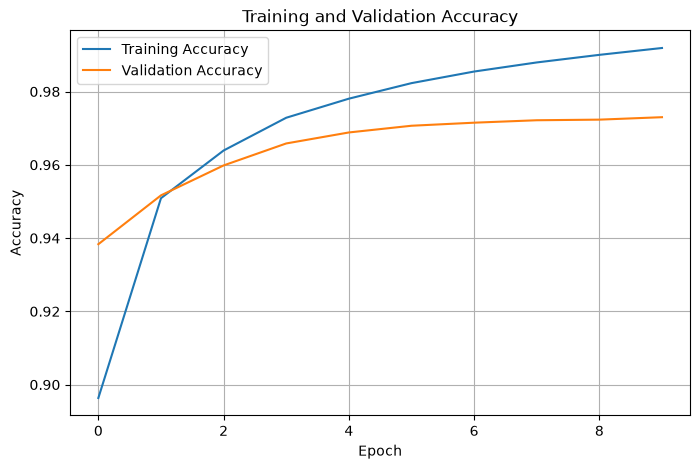

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()


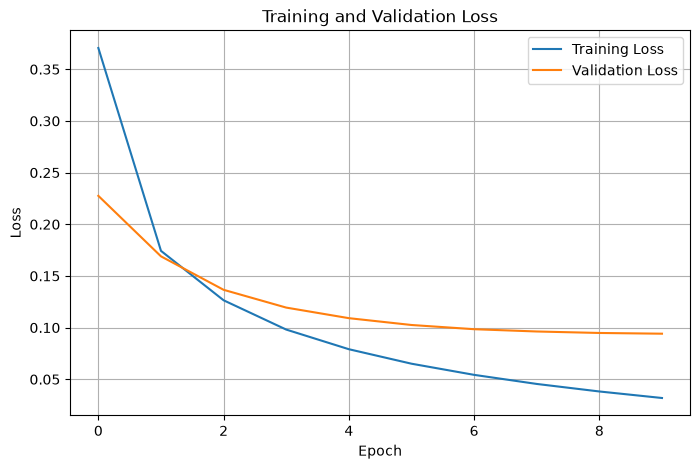

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [16]:
test_loss, test_accuracy = baseline_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 0.08161737024784088
Test Accuracy: 0.975600004196167


In [17]:
y_pred_prob = baseline_model.predict(X_test, verbose=0)

y_pred = np.argmax(y_pred_prob, axis=1)

print("Prediction probability shape:", y_pred_prob.shape)
print("Predicted labels shape:", y_pred.shape)
print("First 20 actual labels:   ", y_test[:20])
print("First 20 predicted labels:", y_pred[:20])

Prediction probability shape: (10000, 10)
Predicted labels shape: (10000,)
First 20 actual labels:    [7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4]
First 20 predicted labels: [7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4]


Confusion Matrix:
[[ 969    1    0    2    1    2    0    1    2    2]
 [   0 1123    2    3    0    1    2    0    4    0]
 [   4    0 1000    9    1    0    2    5   11    0]
 [   0    0    0  999    0    1    0    2    5    3]
 [   0    0    1    1  955    0    6    2    2   15]
 [   2    1    0   17    1  854    3    2    9    3]
 [   5    3    2    1    2    5  934    0    6    0]
 [   0    5    8    6    1    0    0  997    3    8]
 [   3    0    3    9    3    2    1    3  948    2]
 [   3    4    1    8    7    2    0    4    3  977]]


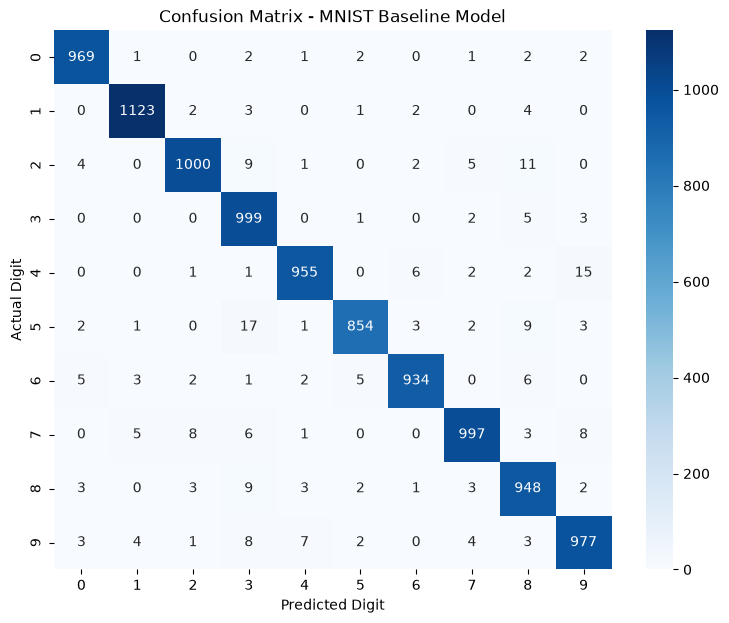

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=range(10),
    yticklabels=range(10)
)

plt.title("Confusion Matrix - MNIST Baseline Model")
plt.xlabel("Predicted Digit")
plt.ylabel("Actual Digit")
plt.show()

In [20]:
from sklearn.metrics import classification_report

report = classification_report(
    y_test,
    y_pred,
    target_names=[str(i) for i in range(10)],
    digits=4
)

print(report)

              precision    recall  f1-score   support

           0     0.9828    0.9888    0.9858       980
           1     0.9877    0.9894    0.9886      1135
           2     0.9833    0.9690    0.9761      1032
           3     0.9469    0.9891    0.9676      1010
           4     0.9835    0.9725    0.9780       982
           5     0.9850    0.9574    0.9710       892
           6     0.9852    0.9749    0.9801       958
           7     0.9813    0.9698    0.9755      1028
           8     0.9547    0.9733    0.9639       974
           9     0.9673    0.9683    0.9678      1009

    accuracy                         0.9756     10000
   macro avg     0.9758    0.9753    0.9754     10000
weighted avg     0.9758    0.9756    0.9756     10000



In [21]:
correct_predictions = np.sum(y_test == y_pred)
incorrect_predictions = np.sum(y_test != y_pred)

print("Total test samples:", len(y_test))
print("Correct predictions:", correct_predictions)
print("Incorrect predictions:", incorrect_predictions)
print("Accuracy:", correct_predictions / len(y_test))
print("Error rate:", incorrect_predictions / len(y_test))

Total test samples: 10000
Correct predictions: 9756
Incorrect predictions: 244
Accuracy: 0.9756
Error rate: 0.0244


In [22]:
from collections import Counter

misclassified_pairs = Counter(
    (actual, predicted)
    for actual, predicted in zip(y_test, y_pred)
    if actual != predicted
)

print("Most common misclassification pairs:\n")

for (actual, predicted), count in misclassified_pairs.most_common(10):
    print(f"Actual {actual} → Predicted {predicted}: {count} cases")

Most common misclassification pairs:

Actual 5 → Predicted 3: 17 cases
Actual 4 → Predicted 9: 15 cases
Actual 2 → Predicted 8: 11 cases
Actual 8 → Predicted 3: 9 cases
Actual 5 → Predicted 8: 9 cases
Actual 2 → Predicted 3: 9 cases
Actual 7 → Predicted 2: 8 cases
Actual 9 → Predicted 3: 8 cases
Actual 7 → Predicted 9: 8 cases
Actual 9 → Predicted 4: 7 cases


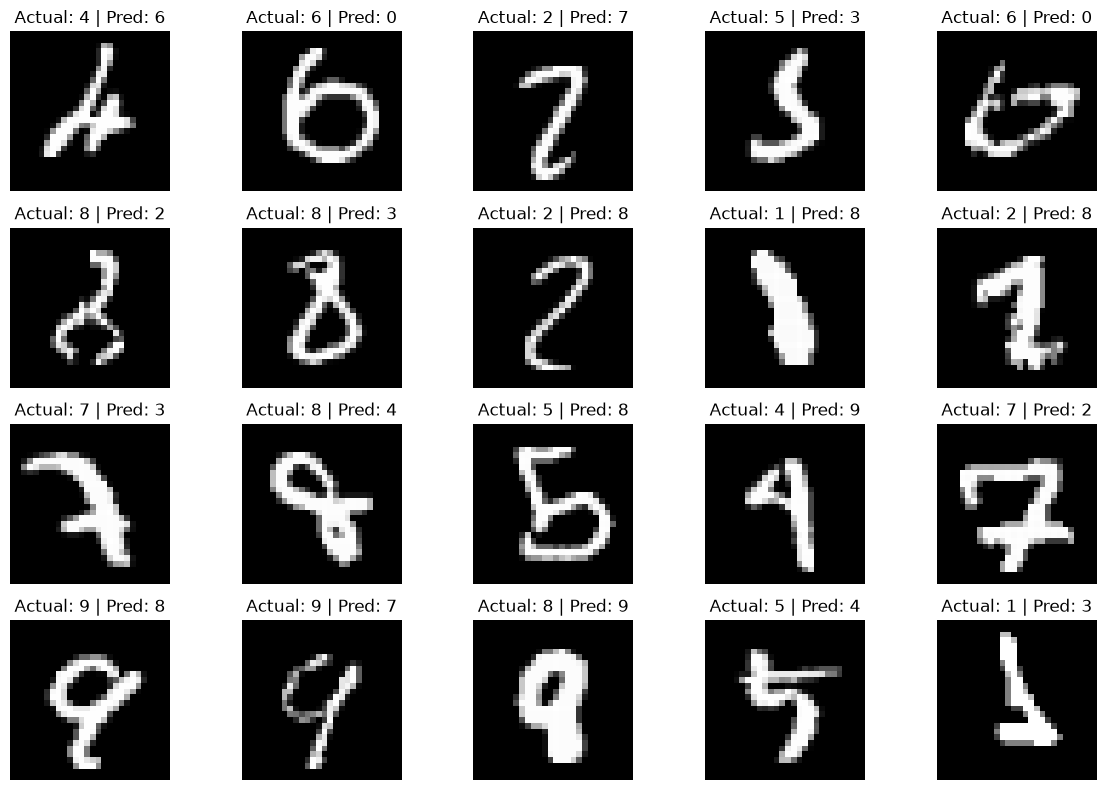

In [23]:
misclassified_indices = np.where(y_test != y_pred)[0]

plt.figure(figsize=(12, 8))

for i, idx in enumerate(misclassified_indices[:20]):
    plt.subplot(4, 5, i + 1)
    plt.imshow(X_test[idx], cmap="gray")
    plt.title(f"Actual: {y_test[idx]} | Pred: {y_pred[idx]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [24]:
# Confidence of each prediction
prediction_confidence = np.max(y_pred_prob, axis=1)

# Confidence for correctly and incorrectly classified samples
correct_mask = (y_test == y_pred)
incorrect_mask = (y_test != y_pred)

print("Average confidence - Correct predictions:",
      prediction_confidence[correct_mask].mean())

print("Average confidence - Incorrect predictions:",
      prediction_confidence[incorrect_mask].mean())

print("Highest confidence among incorrect predictions:",
      prediction_confidence[incorrect_mask].max())

print("Lowest confidence among incorrect predictions:",
      prediction_confidence[incorrect_mask].min())

Average confidence - Correct predictions: 0.9849041
Average confidence - Incorrect predictions: 0.7522204
Highest confidence among incorrect predictions: 0.9998865
Lowest confidence among incorrect predictions: 0.3475077


In [25]:
import numpy as np

total_params = baseline_model.count_params()
parameter_memory_kb = (total_params * 4) / 1024  # float32 = 4 bytes

print("Total trainable parameters:", total_params)
print(f"Approximate parameter memory: {parameter_memory_kb:.2f} KB")

Total trainable parameters: 101770
Approximate parameter memory: 397.54 KB


In [26]:
X_train_cnn = X_train[..., np.newaxis]
X_val_cnn = X_val[..., np.newaxis]
X_test_cnn = X_test[..., np.newaxis]

print("CNN training shape:", X_train_cnn.shape)
print("CNN validation shape:", X_val_cnn.shape)
print("CNN test shape:", X_test_cnn.shape)

CNN training shape: (54000, 28, 28, 1)
CNN validation shape: (6000, 28, 28, 1)
CNN test shape: (10000, 28, 28, 1)


In [27]:
cnn_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),

    tf.keras.layers.Conv2D(
        32, (3, 3), activation="relu", padding="same"
    ),

    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    tf.keras.layers.Conv2D(
        64, (3, 3), activation="relu", padding="same"
    ),

    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation="relu"),

    tf.keras.layers.Dense(10, activation="softmax")
])

cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 14, 14, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 3136)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │         401,536 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Optimizer:", cnn_model.optimizer.name)
print("Loss function:", cnn_model.loss)
print("Metrics:", cnn_model.metrics_names)

Optimizer: adam_1
Loss function: sparse_categorical_crossentropy
Metrics: ['loss', 'compile_metrics']


In [29]:
cnn_history = cnn_model.fit(
    X_train_cnn,
    y_train,
    validation_data=(X_val_cnn, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 18s 40ms/step - accuracy: 0.9362 - loss: 0.2108 - val_accuracy: 0.9787 - val_loss: 0.0704
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 17s 39ms/step - accuracy: 0.9837 - loss: 0.0525 - val_accuracy: 0.9832 - val_loss: 0.0580
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 17s 41ms/step - accuracy: 0.9889 - loss: 0.0362 - val_accuracy: 0.9843 - val_loss: 0.0518
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 17s 40ms/step - accuracy: 0.9918 - loss: 0.0262 - val_accuracy: 0.9845 - val_loss: 0.0516
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 17s 40ms/step - accuracy: 0.9942 - loss: 0.0186 - val_accuracy: 0.9860 - val_loss: 0.0518
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 18s 43ms/step - accuracy: 0.9956 - loss: 0.0145 - val_accuracy: 0.9868 - val_loss: 0.0495
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 23s 55ms/step - accuracy: 0.9961 - loss: 0.0127 - val_accuracy: 0.9850 - val_loss: 0.0538
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 17s 40ms/step - accuracy: 0.9967 - loss: 0.0099 - 

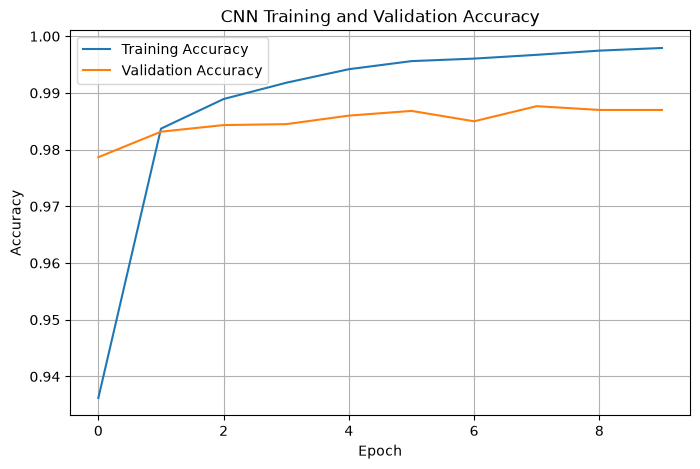

In [30]:
plt.figure(figsize=(8, 5))

plt.plot(cnn_history.history["accuracy"], label="Training Accuracy")
plt.plot(cnn_history.history["val_accuracy"], label="Validation Accuracy")

plt.title("CNN Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

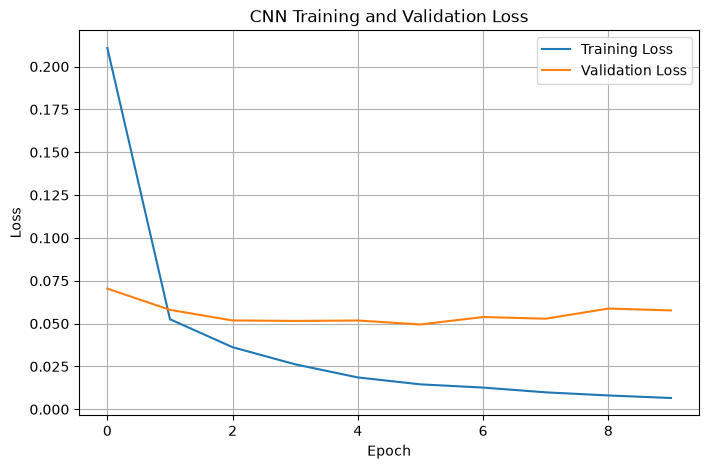

In [31]:
plt.figure(figsize=(8, 5))

plt.plot(cnn_history.history["loss"], label="Training Loss")
plt.plot(cnn_history.history["val_loss"], label="Validation Loss")

plt.title("CNN Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [32]:
cnn_test_loss, cnn_test_accuracy = cnn_model.evaluate(
    X_test_cnn,
    y_test,
    verbose=0
)

print("CNN Test Loss:", cnn_test_loss)
print("CNN Test Accuracy:", cnn_test_accuracy)

CNN Test Loss: 0.03293387591838837
CNN Test Accuracy: 0.9911999702453613


In [33]:
cnn_y_pred_prob = cnn_model.predict(X_test_cnn, verbose=0)

cnn_y_pred = np.argmax(cnn_y_pred_prob, axis=1)

print("CNN prediction probability shape:", cnn_y_pred_prob.shape)
print("CNN predicted labels shape:", cnn_y_pred.shape)
print("First 20 actual labels:   ", y_test[:20])
print("First 20 CNN predictions:", cnn_y_pred[:20])

CNN prediction probability shape: (10000, 10)
CNN predicted labels shape: (10000,)
First 20 actual labels:    [7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4]
First 20 CNN predictions: [7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 8 4]


CNN Confusion Matrix:
[[ 977    0    0    0    0    0    0    1    2    0]
 [   0 1127    1    2    0    0    2    0    3    0]
 [   1    0 1023    0    2    0    2    3    1    0]
 [   1    0    0 1005    0    2    0    0    2    0]
 [   0    0    0    0  969    0    2    1    1    9]
 [   2    1    0    4    0  880    1    0    2    2]
 [   2    2    0    0    2    1  947    0    4    0]
 [   0    1    7    0    0    0    0 1015    1    4]
 [   2    0    1    0    0    0    0    0  970    1]
 [   0    0    1    1    3    1    0    3    1  999]]


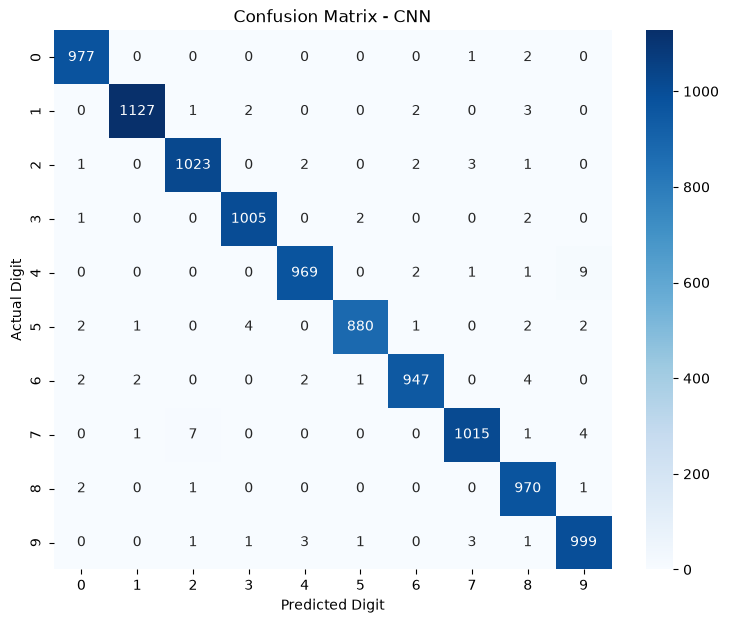

In [34]:
cnn_cm = confusion_matrix(y_test, cnn_y_pred)

print("CNN Confusion Matrix:")
print(cnn_cm)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cnn_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=range(10),
    yticklabels=range(10)
)

plt.title("Confusion Matrix - CNN")
plt.xlabel("Predicted Digit")
plt.ylabel("Actual Digit")
plt.show()

In [35]:
cnn_report = classification_report(
    y_test,
    cnn_y_pred,
    target_names=[str(i) for i in range(10)],
    digits=4
)

print(cnn_report)

              precision    recall  f1-score   support

           0     0.9919    0.9969    0.9944       980
           1     0.9965    0.9930    0.9947      1135
           2     0.9903    0.9913    0.9908      1032
           3     0.9931    0.9950    0.9941      1010
           4     0.9928    0.9868    0.9898       982
           5     0.9955    0.9865    0.9910       892
           6     0.9927    0.9885    0.9906       958
           7     0.9922    0.9874    0.9898      1028
           8     0.9828    0.9959    0.9893       974
           9     0.9842    0.9901    0.9872      1009

    accuracy                         0.9912     10000
   macro avg     0.9912    0.9911    0.9912     10000
weighted avg     0.9912    0.9912    0.9912     10000



In [36]:
print("ANN Test Accuracy:", test_accuracy * 100)
print("CNN Test Accuracy:", cnn_test_accuracy * 100)

print("ANN Parameters:", baseline_model.count_params())
print("CNN Parameters:", cnn_model.count_params())

ANN Test Accuracy: 97.5600004196167
CNN Test Accuracy: 99.11999702453613
ANN Parameters: 101770
CNN Parameters: 421642
